# Padding
Notebook to study the impact of different padding techniques.

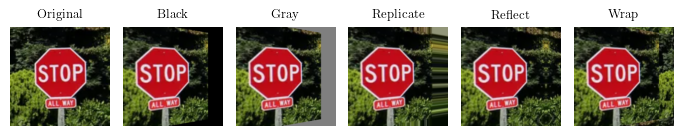

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision.transforms import v2

from vnn.pwl import generate_samples
from vnn.transforms import HomographyYaw, TransformWithBounds
from vnn.visualization import setup_latex, TEXTWIDTH_PT, get_figure_size


PADDINGS = [
    {"name": "Black", "value": 0},
    {"name": "Gray", "value": 0.5},
    {"name": "Replicate", "value": "BORDER_REPLICATE"},
    {"name": "Reflect", "value": "BORDER_REFLECT"},
    {"name": "Wrap", "value": "BORDER_WRAP"},
]
PADDING_VALUE = 0
LOWER = 0
UPPER = np.deg2rad(10)

# Open image
h = w = 256
img_path = Path("stop.png")
img = Image.open(img_path).convert("RGB")
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize((h, w)),
        v2.ToDtype(torch.float32, scale=True),
    ]
)
img = transform(img).numpy()

# Setup transform
xc = w / 2
yc = h / 2
focal_length_px = w / 2
tf = HomographyYaw(f=focal_length_px, xc=xc, yc=yc)
tfwb = TransformWithBounds(tf, LOWER, UPPER)

# Plot
setup_latex()
fig_size = get_figure_size(width_pt=2 * TEXTWIDTH_PT)
fig, axes = plt.subplots(1, len(PADDINGS) + 1, figsize=fig_size)

# Keep color scale constant for each sample
vmin = img.min()
vmax = img.max()
axes[0].imshow(img.transpose(1, 2, 0), cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, padding in zip(axes[1:], PADDINGS):
    samples, params = generate_samples(
        img,
        tfwb.transform,
        lower_bound=tfwb.lower_bound,
        upper_bound=tfwb.upper_bound,
        num_samples=2,
        padding=padding["value"],
    )

    ax.imshow(samples[-1].transpose(1, 2, 0), cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"{padding['name']}")
    ax.axis("off")

fig.tight_layout()
fig.savefig("padding.pdf")